# Section 4: Sensitivity Analysis

Runs Rosenbaum bounds on the Section 1 PSM matched-pairs estimate at the calibrated
confounding severity, then produces the one bounded LLM diagnostic critique for the whole
project (see `src/llm_critique/critique.py` for why it's scoped this narrowly).

This notebook loads the confounded subsample (with propensity attached) that
`01_validation.ipynb` saved to `data/interim/confounded_strong_with_propensity.parquet`,
rather than re-running the whole calibration pipeline.

In [1]:
import os, sys

# Jupyter sets the kernel's cwd to this notebook's own folder (notebooks/),
# but src/ lives one level up, as a sibling of notebooks/, not a child of it.
# This makes 'from src...' imports resolve regardless of how the notebook
# was launched (jupyter notebook from the project root vs from notebooks/).
_cwd = os.getcwd()
_project_root = os.path.dirname(_cwd) if os.path.basename(_cwd) == "notebooks" else _cwd
if _project_root not in sys.path:
    sys.path.insert(0, _project_root)


In [ ]:
import json
import os

import numpy as np
import pandas as pd

from src.utils.logging_config import configure_logging
from src.validation.estimators import get_matched_pairs
from src.validation.diagnostics import run_full_diagnostics
from src.sensitivity.rosenbaum import compute_rosenbaum_bounds, find_critical_gamma, plot_rosenbaum_bounds
from src.llm_critique.critique import run_diagnostic_critique

configure_logging()

os.makedirs("../data/processed", exist_ok=True)

FEATURE_COLS = [f"f{i}" for i in range(12)]
RANDOM_STATE = 42  # must match 01_validation.ipynb so matching is reproducible across notebooks
ALPHA = 0.05
GAMMA_MAX = 10.0

## 1. Load the confounded subsample from Section 1

If this file doesn't exist, run `01_validation.ipynb` through the end first — Section 4
deliberately reuses Section 1's calibrated confounding rather than re-deriving it.

In [3]:
interim_path = "../data/interim/confounded_strong_with_propensity.parquet"

if not os.path.exists(interim_path):
    raise FileNotFoundError(
        f"{interim_path} not found. Run 01_validation.ipynb through Section 8 first; "
        "this notebook reuses its calibrated confounding severity rather than re-deriving it."
    )

strong_retained = pd.read_parquet(interim_path)
print(strong_retained.shape)
strong_retained.head()

(148606, 17)


,f0,f1,f2,f3,f4,f5,f6,f7,f8,f9,f10,f11,treatment,conversion,visit,exposure,_propensity
0,25.744310,10.059654,8.214383,4.679882,10.280525,4.115453,-3.282109,4.833815,3.971858,13.190056,5.300375,-0.168679,1,0,0,0,0.835354
1,12.616365,10.059654,9.007057,4.679882,10.280525,4.115453,0.294443,4.833815,3.890052,13.190056,5.300375,-0.168679,1,0,0,0,0.829320
2,14.070637,10.059654,8.214383,-2.345693,10.280525,4.115453,-16.479126,4.833815,3.971858,13.190056,5.300375,-0.168679,1,0,0,0,0.861693
3,22.709732,10.059654,8.399186,4.679882,10.280525,4.115453,-5.116672,4.833815,3.910792,24.452088,5.300375,-0.168679,1,0,0,0,0.868249
4,22.288802,10.059654,8.876330,4.679882,10.280525,4.115453,-10.764422,4.833815,3.853396,13.190056,5.300375,-0.168679,1,0,0,0,0.833603


## 2. Rebuild diagnostics and matched pairs

`run_full_diagnostics` builds the matched sample internally via `get_matched_pairs`, so this
recomputes balance/overlap diagnostics on the actual matched pairs (not on the
common-support-trimmed sample, which understates matching's effect on balance).

In [ ]:
diagnostics = run_full_diagnostics(
    strong_retained, FEATURE_COLS, "treatment", "_propensity", random_state=RANDOM_STATE
)

print("Imbalanced covariates after matching:", diagnostics["n_imbalanced_covariates"])
print("Percent within common support:", diagnostics["pct_within_overlap"])
print(
    f"Matched {diagnostics['n_pairs']:,} of {diagnostics['n_treated_total']:,} treated units "
    f"({100 * diagnostics['match_rate']:.1f}%) against {diagnostics['n_control_unique']:,} distinct controls"
)
diagnostics["balance_table"]


In [5]:
matched = diagnostics["matched_df"]
print("Matched sample size:", len(matched))

Matched sample size: 251964


## 3. Rosenbaum bounds

Rosenbaum bounds are computed on the matched-pairs output specifically, not on IPW/AIPW
estimates — there is no equivalent matched-pair structure for a weighting-based estimator, so
this method applies to PSM output only (see `src/sensitivity/rosenbaum.py` docstring).

In [6]:
bounds_df = compute_rosenbaum_bounds(
    matched,
    outcome_col="visit",
    treatment_col="treatment",
    gamma_range=np.arange(1.0, GAMMA_MAX + 0.05, 0.1),
)
bounds_df.to_csv("../data/processed/rosenbaum_bounds.csv", index=False)

critical_gamma_result = find_critical_gamma(
    matched,
    outcome_col="visit",
    treatment_col="treatment",
    alpha=ALPHA,
    gamma_max=GAMMA_MAX,
)
print(critical_gamma_result)

14:39:29.801 Critical gamma = 1.35: unmeasured confounding of this odds-ratio strength would be needed to overturn the conclusion at alpha=0.050
{'critical_gamma': 1.3500000000000003, 'gamma_max_checked': 10.0, 'alpha': 0.05, 'n_pairs': 125982, 'n_discordant': 11194, 'n_plus': 6499, 'n_minus': 4695}


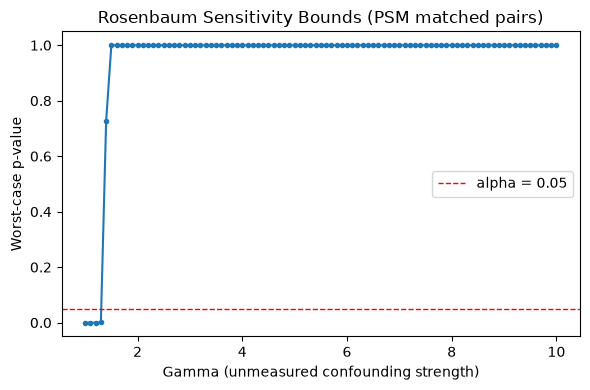

In [7]:
fig = plot_rosenbaum_bounds(bounds_df, alpha=ALPHA, title="Rosenbaum Sensitivity Bounds (PSM matched pairs)")
fig.savefig("../data/processed/rosenbaum_bounds.png", dpi=100)

If `critical_gamma` is a small number (close to 1), the matched-pairs conclusion is fragile:
even modest unmeasured confounding could overturn it. A `critical_gamma` of None (never crossed
alpha up to `gamma_max`) means the conclusion is robust to substantial hidden bias at this
confounding severity.

## 4. The one LLM step in this project

Reads the balance table, overlap diagnostics, and the Rosenbaum critical-gamma result, and
produces a short plain-language flag of likely assumption violations. This is a bounded
diagnostic utility, not a narrative report generator — nothing else in the project calls an
LLM.

In [8]:
critique_result = run_diagnostic_critique(
    diagnostics,
    {"critical_gamma_result": critical_gamma_result},
)

print("Source:", critique_result["source"])
print()
print(critique_result["critique_text"])

with open("../data/processed/critique.json", "w") as f:
    json.dump(
        {"source": critique_result["source"], "critique_text": critique_result["critique_text"]},
        f,
    )

Logfire project URL: https://logfire-us.pydantic.dev/abhinewnpc/ticket-triage-mlops

14:39:32.413 HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 200 OK"
14:39:32.427 Diagnostic critique generated via groq
Source: groq

- The measured variables look well‑matched; after adjustment every covariate’s difference is well below the 0.1 threshold, so observed confounding appears under control.  
- All treated and control units fall inside the overlapping region of propensity scores (100 % within 0.822 – 0.951), so the groups are comparable where the analysis is performed.  
- The Rosenbaum test shows the result could be flipped if an unmeasured factor made a unit about **35 % more likely** to receive the treatment (Γ ≈ 1.35). In plain terms, a modest hidden bias could overturn the finding.  
- Because the sensitivity bound is relatively low, the causal claim should be treated as **somewhat vulnerable** to unobserv


If `source` is `rule_based_fallback`, no Groq/NIM API key was configured in this environment
(set `GROQ_API_KEY` or `NVIDIA_NIM_API_KEY`). The fallback mirrors the kind of flags an actual
LLM call would produce, so the pipeline stays runnable without a key, but it should not be
mistaken for the real LLM critique — the dashboard labels this distinction explicitly.

## Summary

- Reused Section 1's calibrated confounding severity and matched-pairs sample rather than
  re-deriving it.
- Computed Rosenbaum bounds specifically on the PSM matched pairs, found the critical Gamma.
- Ran the project's single bounded LLM diagnostic critique step on the Section 1/4 diagnostics.

This completes Sections 1 through 4. Remaining: the Streamlit dashboard
(`streamlit run dashboard/app.py`) ties all of this together, and the README documents the
full narrative and the deliberate exclusions.